In [27]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
import random
import timm


# ── Dataset ────────────────────────────────────────────────────────────────────

class SkinDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.data = self.data.dropna()
        self.data = self.data[self.data["Disease"] != ""].reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.data["Disease"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path   = self.data.iloc[idx]["Image_Path"]
        label_name = self.data.iloc[idx]["Disease"]
        label      = self.class_to_idx[label_name]
        image      = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


# ── MixUp ──────────────────────────────────────────────────────────────────────

def mixup(images, labels, alpha=0.4):
    lam = torch.distributions.Beta(
        torch.tensor(alpha), torch.tensor(alpha)
    ).sample().item()
    idx      = torch.randperm(images.size(0))
    mixed    = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam


# ── Custom Augmentations ───────────────────────────────────────────────────────

class RandomSharpness:
    """Randomly sharpen or blur the image."""
    def __call__(self, img):
        factor = random.uniform(0.5, 2.5)
        return TF.adjust_sharpness(img, factor)

class RandomGamma:
    """Randomly adjust gamma — simulates different lighting conditions."""
    def __call__(self, img):
        gamma = random.uniform(0.7, 1.5)
        return TF.adjust_gamma(img, gamma)

class RandomAutocontrast:
    """Apply autocontrast randomly — helps with varied skin tones."""
    def __init__(self, p=0.3):
        self.p = p
    def __call__(self, img):
        if random.random() < self.p:
            return TF.autocontrast(img)
        return img


# ── Transforms ─────────────────────────────────────────────────────────────────
# Extra augmentations added: Sharpness, Gamma, Autocontrast, stronger Erasing,
# AutoAugment (ImageNet policy) — all help the model generalise from 100 images.

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),              # slightly larger then random crop
    transforms.RandomCrop(224),                 # random crop instead of fixed resize
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    RandomSharpness(),
    RandomGamma(),
    RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),  # stronger erasing
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),                 # matches train crop size
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


# ── Dataset & Split ────────────────────────────────────────────────────────────

full_dataset = SkinDataset("final_neural_network_data.csv", transform=None)
print("Classes:", full_dataset.classes)
print(f"Total images: {len(full_dataset)}")

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_set, val_set = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_set.dataset.transform = train_transform
val_set.dataset.transform   = val_transform

train_loader = DataLoader(train_set, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)} | Val: {len(val_set)}")


# ── Model ──────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model      = timm.create_model("vit_small_patch16_224", pretrained=True)
model.head = torch.nn.Sequential(
    torch.nn.Dropout(p=0.4),
    torch.nn.Linear(model.head.in_features, len(full_dataset.classes))
)

criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)


# ── Phase 1: Warmup — head only ───────────────────────────────────────────────

for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True

model.to(device)
optimizer_warmup = torch.optim.AdamW(model.head.parameters(), lr=3e-4, weight_decay=1e-4)

print("\n── Phase 1: Warming up head (5 epochs) ──────────────────")
for epoch in range(5):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_warmup.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer_warmup.step()
        total_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds    = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    val_acc = correct / total if total > 0 else 0.0
    print(f"  Warmup {epoch+1}/5 — Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f}")


# ── Phase 2: Full fine-tuning with MixUp ──────────────────────────────────────

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW([
    {"params": [p for name, p in model.named_parameters()
                if "head" not in name], "lr": 1e-5},
    {"params": model.head.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

epochs    = 30
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_acc   = 0.0
patience       = 8
patience_count = 0
best_weights   = None

print("\n── Phase 2: Full fine-tuning with MixUp (up to 30 epochs) ──")
for epoch in range(epochs):

    # ── Train with MixUp ──
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Apply MixUp — blends two images so the model can't memorize exact samples
        images, labels_a, labels_b, lam = mixup(images, labels)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ── Validate (no MixUp on validation) ──
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds    = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    val_acc = correct / total if total > 0 else 0.0
    scheduler.step()

    improved = ""
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
        improved = "  ✓ best"
    else:
        patience_count += 1

    print(f"Epoch {epoch+1:02d}/{epochs} — "
          f"Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} "
          f"| Best: {best_val_acc:.4f}{improved}")

    if patience_count >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")


# ── Save ───────────────────────────────────────────────────────────────────────

torch.save(
    {
        "model_state_dict": best_weights,
        "classes":          full_dataset.classes,
        "class_to_idx":     full_dataset.class_to_idx,
        "model_name":       "vit_small_patch16_224",
    },
    "vit_skin_model.pth",
)
print("Model saved to vit_skin_model.pth")

Classes: ['Acne', 'Contact Dermatitis', 'Eczema', 'Impetigo', 'Skin Cancer', 'Vitiligo', 'Warts', 'psoriasis']
Total images: 103
Train: 82 | Val: 21
Using device: cpu

── Phase 1: Warming up head (5 epochs) ──────────────────
  Warmup 1/5 — Loss: 3.2377 | Val Acc: 0.1429
  Warmup 2/5 — Loss: 2.8872 | Val Acc: 0.1905
  Warmup 3/5 — Loss: 2.6205 | Val Acc: 0.2857
  Warmup 4/5 — Loss: 2.6655 | Val Acc: 0.3333
  Warmup 5/5 — Loss: 2.4704 | Val Acc: 0.3333

── Phase 2: Full fine-tuning with MixUp (up to 30 epochs) ──
Epoch 01/30 — Loss: 2.4937 | Val Acc: 0.4286 | Best: 0.4286  ✓ best
Epoch 02/30 — Loss: 1.9949 | Val Acc: 0.4762 | Best: 0.4762  ✓ best
Epoch 03/30 — Loss: 1.9169 | Val Acc: 0.5238 | Best: 0.5238  ✓ best
Epoch 04/30 — Loss: 1.4170 | Val Acc: 0.4762 | Best: 0.5238
Epoch 05/30 — Loss: 1.5919 | Val Acc: 0.4286 | Best: 0.5238
Epoch 06/30 — Loss: 1.5955 | Val Acc: 0.4762 | Best: 0.5238
Epoch 07/30 — Loss: 1.4027 | Val Acc: 0.4762 | Best: 0.5238
Epoch 08/30 — Loss: 1.2595 | Val Acc: 

C:\Users\Marc\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ ViT loaded on cpu — 8 classes: ['Acne', 'Contact Dermatitis', 'Eczema', 'Impetigo', 'Skin Cancer', 'Vitiligo', 'Warts', 'psoriasis']


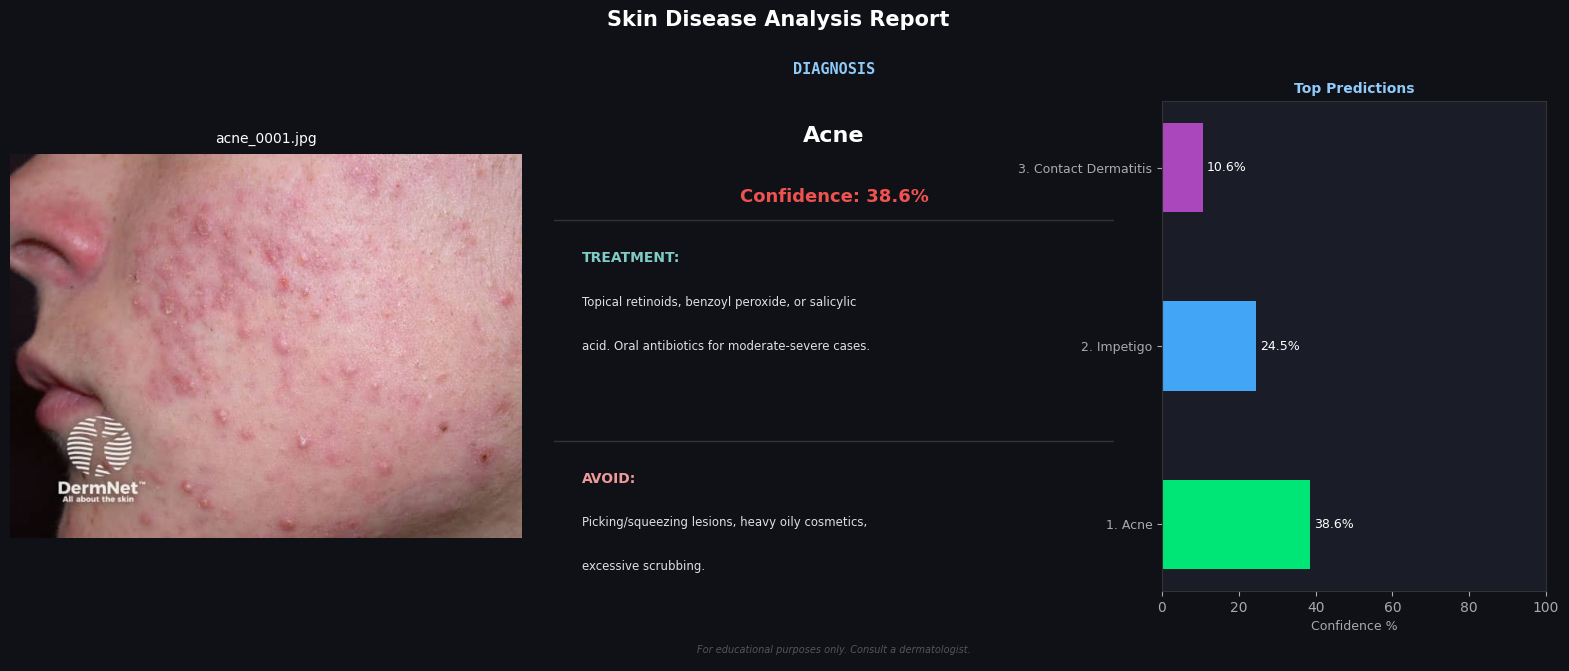

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import timm


# ── Config ─────────────────────────────────────────────────────────────────────

IMG_SIZE   = 224
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "vit_skin_model.pth"


# ── Treatment database ─────────────────────────────────────────────────────────

TREATMENTS = {
    "Acne": (
        "Topical retinoids, benzoyl peroxide, or salicylic acid. "
        "Oral antibiotics for moderate-severe cases.",
        "Picking/squeezing lesions, heavy oily cosmetics, excessive scrubbing."
    ),
    "Contact Dermatitis": (
        "Avoid the trigger allergen, topical corticosteroids, "
        "antihistamines for itch relief.",
        "Known irritants/allergens, scratching, harsh detergents."
    ),
    "Eczema": (
        "Moisturise frequently, topical corticosteroids during flare-ups, "
        "antihistamines for itch relief.",
        "Harsh soaps, hot showers, known allergens, wool clothing."
    ),
    "Impetigo": (
        "Topical mupirocin or oral antibiotics (flucloxacillin). "
        "Keep area clean and covered.",
        "Touching/scratching lesions, close contact with others until healed."
    ),
    "Skin Cancer": (
        "Surgical excision is primary treatment. Immunotherapy or targeted "
        "therapy for advanced stages. Urgent dermatologist referral.",
        "Further UV exposure without protection. Do not delay medical evaluation."
    ),
    "Vitiligo": (
        "Topical corticosteroids, calcineurin inhibitors, phototherapy (NB-UVB). "
        "Cosmetic camouflage if desired.",
        "Excessive sun exposure without SPF 50+ protection, skin trauma."
    ),
    "Warts": (
        "Salicylic acid, cryotherapy (liquid nitrogen), or laser treatment. "
        "Over-the-counter treatments for common warts.",
        "Picking or scratching warts (spreads the virus), walking barefoot in public."
    ),
    "psoriasis": (
        "Topical steroids, vitamin D analogues, phototherapy, "
        "or biologics for severe cases.",
        "Stress, smoking, alcohol, skin injury (Koebner phenomenon)."
    ),
}


# ── Load checkpoint ────────────────────────────────────────────────────────────

checkpoint   = torch.load(MODEL_PATH, map_location=DEVICE)
classes      = checkpoint["classes"]
class_to_idx = checkpoint["class_to_idx"]
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES  = len(classes)

# Rebuild ViT — head must match training script exactly (Dropout + Linear)
model      = timm.create_model("vit_small_patch16_224", pretrained=False)
model.head = torch.nn.Sequential(
    torch.nn.Dropout(p=0.4),
    torch.nn.Linear(model.head.in_features, NUM_CLASSES)
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print(f"✓ ViT loaded on {DEVICE} — {NUM_CLASSES} classes: {classes}")


# ── Helper ─────────────────────────────────────────────────────────────────────

def _draw_wrapped(ax, x, y, text, color, max_w=52, line_h=0.07):
    words, line, lines = text.split(), "", []
    for w in words:
        if len(line) + len(w) + 1 <= max_w:
            line = (line + " " + w).strip()
        else:
            lines.append(line)
            line = w
    if line:
        lines.append(line)
    for i, l in enumerate(lines[:4]):
        ax.text(x, y - i * line_h, l, ha="left", va="top", color=color, fontsize=8.5)


# ── Prediction ─────────────────────────────────────────────────────────────────

def predict(image_path):
    # Must match val_transform in skin_classification.py exactly
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    img    = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0]

    top3_conf, top3_idx = torch.topk(probs, k=min(3, NUM_CLASSES))
    top_disease    = idx_to_class[top3_idx[0].item()]
    top_confidence = top3_conf[0].item()
    treatment, avoid = TREATMENTS.get(
        top_disease, ("No data available", "No data available")
    )

    return {
        "disease":    top_disease,
        "confidence": top_confidence,
        "treatment":  str(treatment),
        "avoid":      str(avoid),
        "top3":       [(idx_to_class[top3_idx[i].item()],
                        top3_conf[i].item()) for i in range(len(top3_idx))],
        "image":      img,
        "probs":      probs.cpu().numpy(),
    }


# ── Visualisation ──────────────────────────────────────────────────────────────

def show_result(result, image_path):
    fig = plt.figure(figsize=(16, 7))
    fig.patch.set_facecolor("#0f1117")

    ax_img = fig.add_axes([0.02, 0.05, 0.32, 0.90])
    ax_img.imshow(result["image"])
    ax_img.axis("off")
    ax_img.set_title(os.path.basename(image_path), color="white", fontsize=10, pad=8)

    ax_info = fig.add_axes([0.36, 0.05, 0.35, 0.90])
    ax_info.set_facecolor("#1a1d27")
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)
    ax_info.axis("off")

    conf_pct   = result["confidence"] * 100
    conf_color = "#00e676" if conf_pct >= 70 else "#ffab40" if conf_pct >= 50 else "#ef5350"

    ax_info.text(0.5, 0.95, "DIAGNOSIS", ha="center", va="top",
                 color="#90caf9", fontsize=11, fontweight="bold", fontfamily="monospace")
    ax_info.text(0.5, 0.85, result["disease"], ha="center", va="top",
                 color="white", fontsize=16, fontweight="bold")
    ax_info.text(0.5, 0.75, f"Confidence: {conf_pct:.1f}%", ha="center", va="top",
                 color=conf_color, fontsize=13, fontweight="bold")

    ax_info.axhline(0.70, color="#333", linewidth=1)
    ax_info.text(0.05, 0.65, "TREATMENT:", ha="left", va="top",
                 color="#80cbc4", fontsize=10, fontweight="bold")
    _draw_wrapped(ax_info, 0.05, 0.58, result["treatment"], color="#e0e0e0")

    ax_info.axhline(0.35, color="#333", linewidth=1)
    ax_info.text(0.05, 0.30, "AVOID:", ha="left", va="top",
                 color="#ef9a9a", fontsize=10, fontweight="bold")
    _draw_wrapped(ax_info, 0.05, 0.23, result["avoid"], color="#e0e0e0")

    ax_info.text(0.5, 0.01,
                 "For educational purposes only. Consult a dermatologist.",
                 ha="center", va="bottom", color="#555", fontsize=7, style="italic")

    ax_bar = fig.add_axes([0.74, 0.15, 0.24, 0.70])
    ax_bar.set_facecolor("#1a1d27")

    names2 = [d for d, _ in result["top3"]]
    confs  = [c for _, c in result["top3"]]
    colors = ["#00e676", "#42a5f5", "#ab47bc"]

    bars = ax_bar.barh(range(len(confs)), [c * 100 for c in confs],
                       color=colors[:len(confs)], height=0.5, edgecolor="none")
    ax_bar.set_xlim(0, 100)
    ax_bar.set_yticks(range(len(confs)))
    ax_bar.set_yticklabels([f"{i+1}. {d}" for i, d in enumerate(names2)],
                            color="white", fontsize=9)
    ax_bar.set_xlabel("Confidence %", color="#aaa", fontsize=9)
    ax_bar.tick_params(colors="#aaa")
    ax_bar.spines[:].set_color("#333")
    ax_bar.set_title("Top Predictions", color="#90caf9", fontsize=10, fontweight="bold")
    for bar, c in zip(bars, confs):
        ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                    f"{c*100:.1f}%", va="center", color="white", fontsize=9)

    plt.suptitle("Skin Disease Analysis Report", color="white",
                 fontsize=15, fontweight="bold", y=0.98)
    plt.show()


# ── Run ────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    IMAGE_PATH = r"C:\Users\Marc\OneDrive\Desktop\nn\skin_disease_dataset2222\acne\acne_0001.jpg"  # ← replace with your image path
    result = predict(IMAGE_PATH)
    show_result(result, IMAGE_PATH)